# 🛒 Proyek Akhir Data Mining
## Preprocessing & Unsupervised Learning — K-Means Clustering

**Dataset**: Mall Customer Segmentation  
**Algoritma**: K-Means Clustering  
**Tools**: Python, Pandas, Scikit-Learn, Matplotlib, Seaborn

## 📦 Import Library

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport')

Library berhasil diimport


## 1️⃣ Load Dataset Mentah

In [12]:
df_raw = pd.read_csv('/workspaces/UAS-DATA-MINING/data/mall_customers_raw.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (220, 5)


,CustomerID,Gender,Age,Annual_Income_k,Spending_Score
0,1,female,20.0,34.0,10.0
1,2,M,66.0,79.0,73.0
2,3,male,54.0,22.0,24.0
3,4,M,66.0,124.0,64.0
4,5,M,34.0,30.0,99.0


In [13]:
# Cek info dasar
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       220 non-null    int64  
 1   Gender           220 non-null    str    
 2   Age              207 non-null    float64
 3   Annual_Income_k  209 non-null    float64
 4   Spending_Score   211 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 8.7 KB


In [14]:
# Statistik deskriptif
df_raw.describe()

,CustomerID,Age,Annual_Income_k,Spending_Score
count,220.000000,207.000000,209.000000,211.000000
mean,103.622727,44.502415,78.846890,48.848341
std,60.709341,14.899949,36.699868,29.545538
min,1.000000,18.000000,15.000000,1.000000
25%,51.750000,34.000000,47.000000,22.000000
50%,101.500000,46.000000,78.000000,47.000000
75%,156.000000,56.000000,110.000000,74.000000
max,210.000000,69.000000,136.000000,100.000000


## 2️⃣ Cleaning Data

In [15]:
df = df_raw.copy()

# --- Missing Values ---
print('Missing values per kolom:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per kolom:
CustomerID          0
Gender              0
Age                13
Annual_Income_k    11
Spending_Score      9
dtype: int64

Total missing: 33


In [16]:
# Imputasi dengan median
for col in ['Age', 'Annual_Income_k', 'Spending_Score']:
    df[col].fillna(df[col].median(), inplace=True)

print(f'Missing values setelah imputasi: {df.isnull().sum().sum()}')

Missing values setelah imputasi: 33


In [17]:
# --- Duplikat ---
print(f'Jumlah duplikat: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape setelah drop duplikat: {df.shape}')

Jumlah duplikat: 10
Shape setelah drop duplikat: (210, 5)


In [18]:
# --- Standarisasi Gender ---
print('Sebelum:', df['Gender'].unique())
df['Gender'] = df['Gender'].str.lower().str.strip()
df['Gender'] = df['Gender'].replace({'m': 'male', 'f': 'female'})
print('Sesudah:', df['Gender'].unique())

# Encoding
df['Gender_Enc'] = df['Gender'].map({'male': 0, 'female': 1})
df.head()

Sebelum: <StringArray>
['female', 'M', 'male', 'Female', 'F', 'Male']
Length: 6, dtype: str
Sesudah: <StringArray>
['female', 'male']
Length: 2, dtype: str


,CustomerID,Gender,Age,Annual_Income_k,Spending_Score,Gender_Enc
0,1,female,20.0,34.0,10.0,1
1,2,male,66.0,79.0,73.0,0
2,3,male,54.0,22.0,24.0,0
3,4,male,66.0,124.0,64.0,0
4,5,male,34.0,30.0,99.0,0


## 3️⃣ Scaling / Normalisasi

In [19]:
features = ['Age', 'Annual_Income_k', 'Spending_Score']
X = df[features].dropna()
df = df.loc[X.index].reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Statistik setelah StandardScaler:')
pd.DataFrame(X_scaled, columns=features).describe().round(3)

Statistik setelah StandardScaler:


,Age,Annual_Income_k,Spending_Score
count,181.000,181.000,181.000
mean,-0.000,-0.000,-0.000
std,1.003,1.003,1.003
min,-1.685,-1.783,-1.630
25%,-0.690,-0.882,-0.879
50%,0.039,0.018,-0.060
75%,0.769,0.891,0.861
max,1.697,1.519,1.748


## 4️⃣ Menentukan K Optimal

In [20]:
inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

best_k = list(k_range)[np.argmax(silhouettes)]
print(f'K terbaik: {best_k} (Silhouette Score: {max(silhouettes):.4f})')

K terbaik: 7 (Silhouette Score: 0.3294)


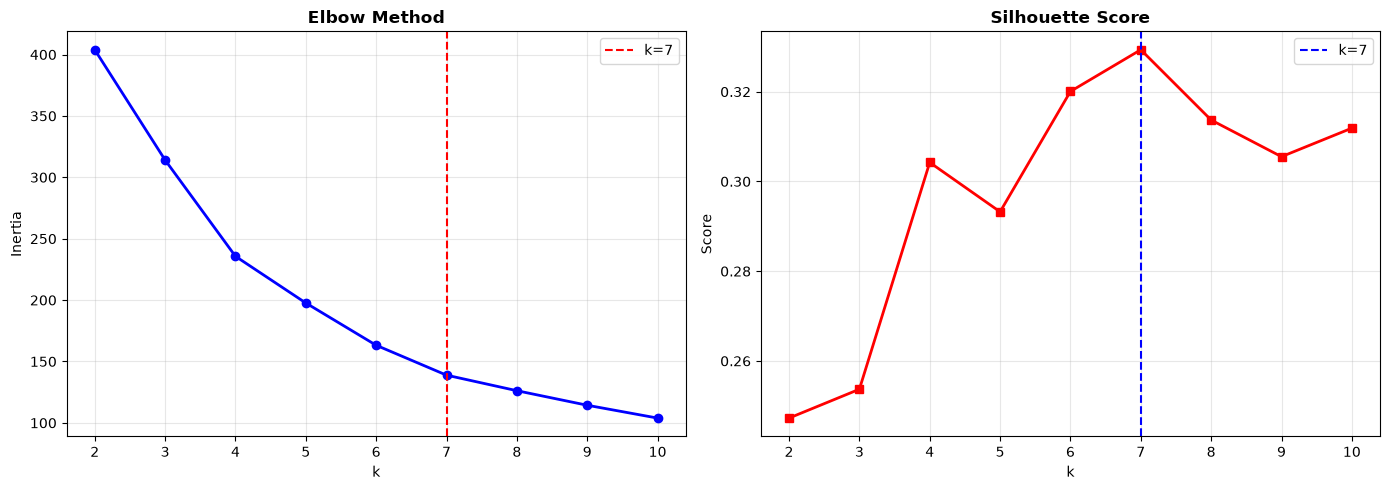

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, 'bo-', linewidth=2)
ax1.axvline(best_k, color='red', linestyle='--', label=f'k={best_k}')
ax1.set_title('Elbow Method', fontweight='bold')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(list(k_range), silhouettes, 'rs-', linewidth=2)
ax2.axvline(best_k, color='blue', linestyle='--', label=f'k={best_k}')
ax2.set_title('Silhouette Score', fontweight='bold')
ax2.set_xlabel('k'); ax2.set_ylabel('Score')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5️⃣ K-Means Clustering

In [22]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, df['Cluster'])
print(f'Silhouette Score: {final_sil:.4f}')
print('\nDistribusi cluster:')
print(df['Cluster'].value_counts().sort_index())

Silhouette Score: 0.3294

Distribusi cluster:
Cluster
0    28
1    26
2    13
3    28
4    34
5    25
6    27
Name: count, dtype: int64


In [23]:
# Profil tiap cluster
df.groupby('Cluster')[features].mean().round(2)

,Age,Annual_Income_k,Spending_Score
Cluster,,,
0,53.39,122.29,28.18
1,33.96,45.50,75.81
2,23.15,29.15,19.92
3,36.00,113.14,80.54
4,54.68,51.32,28.21
5,61.24,79.84,76.16
6,28.89,98.04,25.56


## 6️⃣ Visualisasi Hasil Clustering

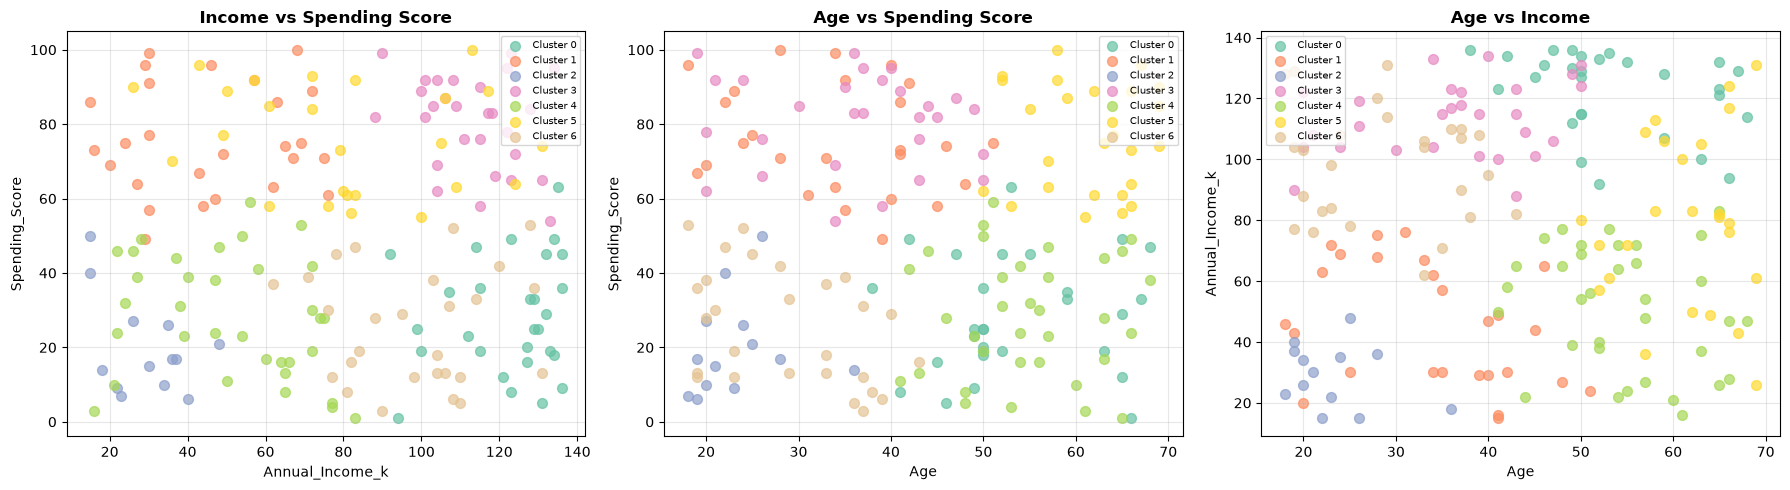

In [24]:
palette = sns.color_palette('Set2', best_k)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [
    ('Annual_Income_k', 'Spending_Score', 'Income vs Spending Score'),
    ('Age', 'Spending_Score', 'Age vs Spending Score'),
    ('Age', 'Annual_Income_k', 'Age vs Income'),
]

for ax, (x_col, y_col, title) in zip(axes, pairs):
    for i in range(best_k):
        mask = df['Cluster'] == i
        ax.scatter(df.loc[mask, x_col], df.loc[mask, y_col],
                   c=[palette[i]], label=f'Cluster {i}', s=50, alpha=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

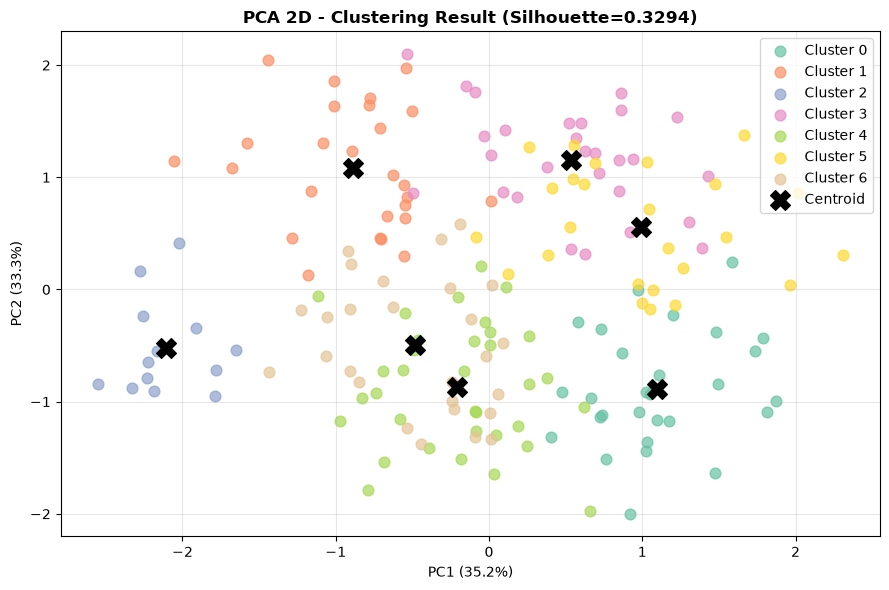

In [25]:
# PCA 2D Visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
for i in range(best_k):
    mask = df['Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[palette[i]], label=f'Cluster {i}', s=60, alpha=0.7)

centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroid')

plt.title(f'PCA 2D - Clustering Result (Silhouette={final_sil:.4f})', fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7️⃣ Simpan Hasil

In [26]:
df.to_csv('/workspaces/UAS-DATA-MINING/data/mall_customers_with_clusters.csv', index=False)
print('Dataset dengan cluster disimpan!')
print(f'\n📊 Ringkasan:')
print(f'   Dataset awal    : 220 baris')
print(f'   Setelah cleaning: {len(df)} baris')
print(f'   Jumlah cluster  : {best_k}')
print(f'   Silhouette Score: {final_sil:.4f}')

Dataset dengan cluster disimpan!

📊 Ringkasan:
   Dataset awal    : 220 baris
   Setelah cleaning: 181 baris
   Jumlah cluster  : 7
   Silhouette Score: 0.3294


##  Kesimpulan

Preprocessing berhasil membersihkan dataset dari missing values, duplikat, dan inkonsistensi format. K-Means Clustering dengan k=7 menghasilkan segmentasi pelanggan yang bermakna berdasarkan usia, pendapatan, dan skor belanja. Cluster dengan income tinggi dan spending score tinggi merupakan target pemasaran paling potensial.